In [1]:
!pip install pmdarima


[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath('../../'))
from src.analysis.metrics import calculate_rmse, calculate_mape

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error

In [3]:
# Restaurant data with the 25 most frequent ingredients
daily_consumption_df = pd.read_csv('../../data/restaurant_daily_consumption.csv', index_col=0, parse_dates=True)
display(daily_consumption_df)

,Salt,Sugar,Clove,Paprika
Date,,,,
2019-01-01,153.557043,1573.765650,0.097426,2.455129
2019-01-02,101.122931,1036.382257,0.064158,1.616792
2019-01-03,119.849399,1228.304898,0.076040,1.916198
2019-01-04,97.377637,997.997729,0.061782,1.556911
2019-01-05,202.245861,2072.764515,0.128317,3.233584
...,...,...,...,...
2019-06-26,116.104106,1189.920370,0.073663,1.856317
2019-06-27,205.991155,2111.149043,0.130693,3.293465
2019-06-28,179.774099,1842.457347,0.114059,2.874297


In [4]:
from scipy.stats import boxcox
from scipy.special import inv_boxcox 

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=8.58 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1243.988, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=1011.288, Time=1.27 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=399.426, Time=1.37 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=398.446, Time=3.38 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=2.52 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=inf, Time=7.26 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=inf, Time=5.87 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=1.43 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=8.67 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=273.431, Time=6.08 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=316.393, Time=2.38 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=298.424, Time=1.89 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=262.297, Time=7.26 sec
 ARIMA(3

c:\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


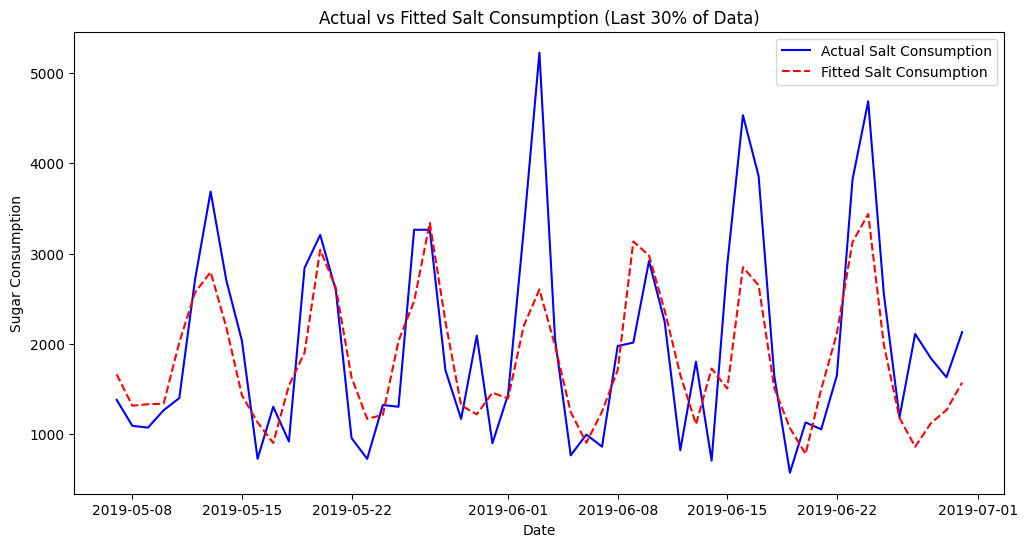

In [5]:
# Fit the ARIMA model on the entire dataset (log transformation optional)
data_salt = daily_consumption_df['Sugar']
data_salt_log = np.log(data_salt)

# Use auto_arima to find the best parameters for ARIMA
model_salt_log = auto_arima(data_salt_log, seasonal=False, trace=True)

# Fit ARIMA model on log-transformed data
arima_model_salt_log = ARIMA(data_salt_log, order=model_salt_log.order)
model_fit_salt_log = arima_model_salt_log.fit()

# Generate predictions for the entire dataset
full_salt_pred_log = model_fit_salt_log.fittedvalues
full_salt_pred = np.exp(full_salt_pred_log)  # Inverse the log transformation

# Define the size for the last 30% of data
last_30_percent_index = int(len(daily_consumption_df) * 0.7)
last_30_percent_data = daily_consumption_df[last_30_percent_index:]

# Plot actual vs predicted values for the last 30% of data
plt.figure(figsize=(12,6))
plt.plot(last_30_percent_data.index, last_30_percent_data['Sugar'], label='Actual Salt Consumption', color='blue')
plt.plot(last_30_percent_data.index, full_salt_pred[last_30_percent_index:], label='Fitted Salt Consumption', color='red', linestyle='--')
plt.title('Actual vs Fitted Salt Consumption (Last 30% of Data)')
plt.xlabel('Date')
plt.ylabel('Sugar Consumption')
plt.legend()
plt.show()